In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import geopandas as gpd

In [6]:
df1 = pd.read_csv("mobile-cellular-subscriptions-per-100-people.csv")
df1.head()

,Entity,Code,Year,Mobile cellular subscriptions (per 100 people)
0,Afghanistan,AFG,1980,0.0
1,Afghanistan,AFG,1981,0.0
2,Afghanistan,AFG,1982,0.0
3,Afghanistan,AFG,1983,0.0
4,Afghanistan,AFG,1984,0.0


In [8]:
df2 = pd.read_csv("number-of-internet-users.csv")
df2.head()

,Entity,Code,Year,Number of Internet users
0,Afghanistan,AFG,1990,0.0
1,Afghanistan,AFG,1991,0.0
2,Afghanistan,AFG,1992,0.0
3,Afghanistan,AFG,1993,0.0
4,Afghanistan,AFG,1994,0.0


In [10]:
df3 = pd.read_csv("share-of-individuals-using-the-internet.csv")
df3.head()

,Entity,Code,Year,Share of the population using the Internet
0,Afghanistan,AFG,1990,0.000000
1,Afghanistan,AFG,2001,0.004723
2,Afghanistan,AFG,2002,0.004561
3,Afghanistan,AFG,2003,0.087891
4,Afghanistan,AFG,2004,0.105809


In [11]:
df1.shape

(9360, 4)

In [12]:
df2.shape

(6675, 4)

In [14]:
df3.shape

(6331, 4)

In [15]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9360 entries, 0 to 9359
Data columns (total 4 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Entity                                          9360 non-null   object 
 1   Code                                            9360 non-null   object 
 2   Year                                            9360 non-null   int64  
 3   Mobile cellular subscriptions (per 100 people)  9360 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 292.6+ KB


In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6675 entries, 0 to 6674
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    6675 non-null   object 
 1   Code                      6675 non-null   object 
 2   Year                      6675 non-null   int64  
 3   Number of Internet users  6675 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.7+ KB


In [17]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6331 entries, 0 to 6330
Data columns (total 4 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Entity                                      6331 non-null   object 
 1   Code                                        6331 non-null   object 
 2   Year                                        6331 non-null   int64  
 3   Share of the population using the Internet  6331 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 198.0+ KB


In [160]:
df1.describe()

,Year,Mobile_Subscriptions/100
count,5863.000000,5863.000000
mean,2005.506055,54.949967
std,9.222038,54.931040
min,1990.000000,0.000000
25%,1998.000000,1.243617
50%,2005.000000,40.764900
75%,2013.000000,102.744500
max,2021.000000,416.261000


In [161]:
df2.describe()

,Year,Internet_Users
count,5666.000000,5.666000e+03
mean,2005.366573,7.813712e+06
std,9.212732,4.322781e+07
min,1990.000000,0.000000e+00
25%,1997.000000,9.455484e+03
50%,2005.000000,2.094356e+05
75%,2013.000000,2.756983e+06
max,2021.000000,1.042059e+09


In [162]:
df3.describe()

,Year,Internet_Penetration(%)
count,5120.000000,5120.000000
mean,2006.825000,28.604689
std,8.590613,30.987929
min,1990.000000,0.000000
25%,2000.000000,1.319892
50%,2007.000000,14.729400
75%,2014.000000,54.211450
max,2021.000000,100.000000


In [ ]:
#Filtering and aligning the datasets to 1990-2021
df1 = df1[(df1['Year'] >= 1990) & (df1['Year'] <= 2021)]
df2 = df2[(df2['Year'] >= 1990) & (df2['Year'] <= 2021)]
df3 = df3[(df3['Year'] >= 1990) & (df3['Year'] <= 2021)]

In [51]:
df1['Year'].min()

np.int64(1990)

In [164]:
df1['Year'].max()

np.int64(2021)

In [52]:
df1.shape

(5863, 3)

In [ ]:
#Renaming "Entity" to "Country" and drop Code column in all three
df1 = df1.rename(columns={'Entity': 'Country'}).drop(columns=['Code'])
df2 = df2.rename(columns={'Entity': 'Country'}).drop(columns=['Code'])
df3 = df3.rename(columns={'Entity': 'Country'}).drop(columns=['Code'])



KeyError: "['Code'] not found in axis"

In [165]:
df3.head()

,Country,Year,Internet_Penetration(%)
0,Afghanistan,1990,0.000000
1,Afghanistan,2001,0.004723
2,Afghanistan,2002,0.004561
3,Afghanistan,2003,0.087891
4,Afghanistan,2004,0.105809


In [ ]:
#Drop the redundant columns
df3 = df3.drop(columns=['Share of the population using the Internet', 'Internet Penetration Pct'])

KeyError: "['Share of the population using the Internet', 'Internet Penetration Pct'] not found in axis"

In [171]:
#Renaming the last column in df1
df1 = df1.rename(columns={'Mobile_Subscriptions/100)': 'Mobile Subscriptions_Per_100'})

In [172]:
df1.head()

,Country,Year,Mobile_Subscriptions/100
10,Afghanistan,1990,0.0
11,Afghanistan,1991,0.0
12,Afghanistan,1992,0.0
13,Afghanistan,1993,0.0
14,Afghanistan,1994,0.0


In [40]:
#Renaming df2
df2 = df2.rename(columns={'Number of Internet users': 'Internet_Users'})

In [41]:
df2.head()

,Country,Year,Internet_Users
0,Afghanistan,1990,0.0
1,Afghanistan,1991,0.0
2,Afghanistan,1992,0.0
3,Afghanistan,1993,0.0
4,Afghanistan,1994,0.0


In [46]:
import pycountry

#list of all country names
official_countries = {country.name for country in pycountry.countries}

In [ ]:
#Filtering to keep only real countries
df1 = df1[df1['Country'].isin(official_countries)]
df2 = df2[df2['Country'].isin(official_countries)]
df3 = df3[df3['Country'].isin(official_countries)]

In [48]:
print(df1.shape)
print(df2.shape)
print(df3.shape)

(5863, 3)
(5666, 3)
(5120, 3)


In [67]:
#Merging all three datasets to form one dataframe, df
df = df3.merge(df2, on=['Country', 'Year'], how='inner') \
               .merge(df1, on=['Country', 'Year'], how='inner')

In [174]:
df.shape

(5029, 11)

In [84]:
df.head(25)

,Country,Year,Internet_Penetration(%),Internet_Users,Mobile_Subscriptions_Per_100
0,Afghanistan,1990,0.000000,0,0.000000
1,Afghanistan,2001,0.004723,957,0.000000
2,Afghanistan,2002,0.004561,975,0.116942
3,Afghanistan,2003,0.087891,19980,0.879776
4,Afghanistan,2004,0.105809,24929,2.546620
5,Afghanistan,2005,1.224150,298748,4.917110
6,Afghanistan,2006,2.107120,535717,9.913300
7,Afghanistan,2007,1.900000,492287,18.016700
8,Afghanistan,2008,1.840000,487280,29.826800
9,Afghanistan,2009,3.550000,975046,38.228900


In [107]:
df4 = pd.read_csv("gdp-per-capita-worldbank.csv")
df4.head()

,Entity,Code,Year,GDP per capita,World region according to OWID
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


(5029, 10)

In [111]:
df4 = df4.rename(columns={
    'Entity'                        : 'Country',
    'World region according to OWID': 'World_Region'
})

In [113]:
df4 = df4[df4['Year'] <= 2021].copy()

In [114]:
df4.isna().sum()

Country           0
Year              0
GDP_Per_Capita    0
dtype: int64

In [116]:
df4.shape

(6617, 3)

In [117]:
df4 = df4.drop(columns=['World_Region'])

KeyError: "['World_Region'] not found in axis"

In [110]:
df4.head()

,Country,Year,GDP_Per_Capita
0,Afghanistan,2000,1617.8264
1,Afghanistan,2001,1454.1108
2,Afghanistan,2002,1774.3087
3,Afghanistan,2003,1815.9282
4,Afghanistan,2004,1776.9182


In [ ]:
#Merging to the merge dataframe
df = df.merge(df4, on=['Country', 'Year'], how='left')

In [ ]:
#Decades
df['Decade'] = (df['Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(str) + 's'


In [ ]:
#Categorzing the connectivity
def connectivity(pct):
    if pct == 0:
        return 'Unconnected'
    elif pct < 10:
        return 'Low'
    elif pct < 40:
        return 'Medium'
    elif pct < 75:
        return 'High'
    else:
        return 'Fully Connected'

df['Connectivity'] = df['Internet_Penetration(%)'].apply(connectivity)

In [89]:
#Growth rate per country
df = df.sort_values(['Country', 'Year'])
df['Internet_Growth_Rate'] = df.groupby('Country')['Internet_Penetration(%)'].pct_change() * 100

In [90]:
#Mobile subscribers and internet subscribers
df['Mobile_Internet_Gap'] = df['Mobile_Subscriptions_Per_100'] - df['Internet_Penetration(%)']

In [119]:
df.head()

,Country,Year,Internet_Penetration(%),Internet_Users,Mobile_Subscriptions_Per_100,Decade,Connectivity,Internet_Growth_Rate,Mobile_Internet_Gap,Region,GDP_Per_Capita
0,Afghanistan,1990,0.000000,0,0.000000,1990s,Unconnected,NaN,0.000000,Asia,NaN
1,Afghanistan,2001,0.004723,957,0.000000,2000s,Low,NaN,-0.004723,Asia,1454.1108
2,Afghanistan,2002,0.004561,975,0.116942,2000s,Low,-3.412760,0.112381,Asia,1774.3087
3,Afghanistan,2003,0.087891,19980,0.879776,2000s,Low,1826.849213,0.791885,Asia,1815.9282
4,Afghanistan,2004,0.105809,24929,2.546620,2000s,Low,20.386204,2.440811,Asia,1776.9182


In [120]:
#Regions
region_map = {
    'Africa': ['Kenya', 'Nigeria', 'Ethiopia', 'Ghana', 'Uganda', 'Rwanda',
               'Egypt', 'South Africa', 'Algeria', 'Morocco', 'Angola',
               'Cameroon', 'Senegal', 'Zimbabwe', 'Zambia', 'Mozambique',
               'Madagascar', 'Mali', 'Malawi', 'Niger', 'Chad', 'Somalia',
               'Sudan', 'Tunisia', 'Libya', 'Togo', 'Benin', 'Burundi',
               'Central African Republic', 'Eritrea', 'Gabon', 'Gambia',
               'Guinea', 'Guinea-Bissau', 'Lesotho', 'Liberia', 'Mauritania',
               'Mauritius', 'Namibia', 'Sierra Leone', 'Eswatini', 'Botswana',
               'Djibouti', 'Comoros', 'Cabo Verde', 'Seychelles'],
    'Asia': ['China', 'India', 'Japan', 'South Korea', 'Indonesia',
             'Pakistan', 'Bangladesh', 'Vietnam', 'Thailand', 'Malaysia',
             'Philippines', 'Myanmar', 'Afghanistan', 'Iraq', 'Iran',
             'Saudi Arabia', 'United Arab Emirates', 'Israel', 'Jordan',
             'Lebanon', 'Syria', 'Yemen', 'Oman', 'Kuwait', 'Qatar',
             'Bahrain', 'Nepal', 'Sri Lanka', 'Cambodia', 'Laos',
             'Mongolia', 'Bhutan', 'Maldives', 'Brunei', 'Singapore',
             'Kazakhstan', 'Uzbekistan', 'Turkmenistan', 'Tajikistan',
             'Kyrgyzstan', 'Azerbaijan', 'Armenia', 'Georgia'],
    'Europe': ['Germany', 'France', 'United Kingdom', 'Italy', 'Spain',
               'Netherlands', 'Belgium', 'Sweden', 'Norway', 'Denmark',
               'Finland', 'Switzerland', 'Austria', 'Poland', 'Portugal',
               'Greece', 'Czech Republic', 'Hungary', 'Romania', 'Bulgaria',
               'Croatia', 'Slovakia', 'Slovenia', 'Estonia', 'Latvia',
               'Lithuania', 'Luxembourg', 'Malta', 'Cyprus', 'Iceland',
               'Ireland', 'Serbia', 'Albania', 'Bosnia and Herzegovina',
               'Montenegro', 'North Macedonia', 'Moldova', 'Ukraine',
               'Belarus', 'Russia', 'Turkey', 'Andorra', 'Monaco',
               'Liechtenstein', 'San Marino'],
    'North America': ['United States', 'Canada', 'Mexico', 'Cuba',
                      'Jamaica', 'Haiti', 'Dominican Republic',
                      'Guatemala', 'Honduras', 'El Salvador', 'Nicaragua',
                      'Costa Rica', 'Panama', 'Belize', 'Trinidad and Tobago',
                      'Barbados', 'Bahamas', 'Grenada', 'Saint Lucia',
                      'Antigua and Barbuda'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru',
                      'Venezuela', 'Ecuador', 'Bolivia', 'Paraguay',
                      'Uruguay', 'Guyana', 'Suriname'],
    'Oceania': ['Australia', 'New Zealand', 'Papua New Guinea', 'Fiji',
                'Solomon Islands', 'Vanuatu', 'Samoa', 'Tonga',
                'Kiribati', 'Tuvalu', 'Nauru']
}

#Reverse the mapping
country_to_region = {}
for region, countries in region_map.items():
    for country in countries:
        country_to_region[country] = region

#Region column
df['Region'] = df['Country'].map(country_to_region)


In [121]:
df['Region'].value_counts().sum()

np.int64(4544)

In [122]:
df.head()

,Country,Year,Internet_Penetration(%),Internet_Users,Mobile_Subscriptions_Per_100,Decade,Connectivity,Internet_Growth_Rate,Mobile_Internet_Gap,Region,GDP_Per_Capita
0,Afghanistan,1990,0.000000,0,0.000000,1990s,Unconnected,NaN,0.000000,Asia,NaN
1,Afghanistan,2001,0.004723,957,0.000000,2000s,Low,NaN,-0.004723,Asia,1454.1108
2,Afghanistan,2002,0.004561,975,0.116942,2000s,Low,-3.412760,0.112381,Asia,1774.3087
3,Afghanistan,2003,0.087891,19980,0.879776,2000s,Low,1826.849213,0.791885,Asia,1815.9282
4,Afghanistan,2004,0.105809,24929,2.546620,2000s,Low,20.386204,2.440811,Asia,1776.9182


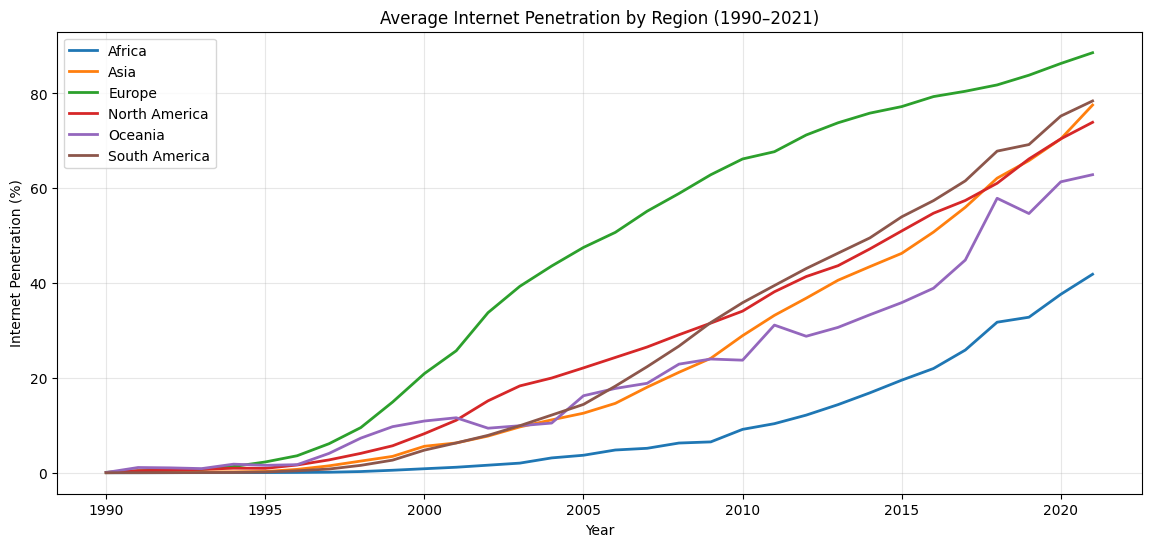

In [123]:
regional_trend = df.groupby(['Region', 'Year'])['Internet_Penetration(%)'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

regions = regional_trend['Region'].unique()

for region in regions:
    data = regional_trend[regional_trend['Region'] == region]
    ax.plot(data['Year'], data['Internet_Penetration(%)'], linewidth=2, label=region)

ax.set_title('Average Internet Penetration by Region (1990–2021)')
ax.set_xlabel('Year')
ax.set_ylabel('Internet Penetration (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show();

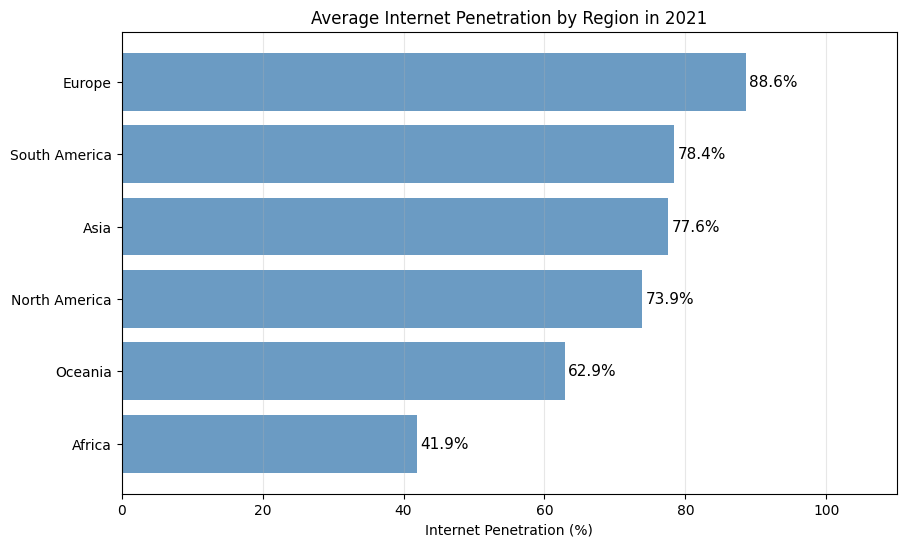

In [ ]:
penetration_2021 = df[df['Year'] == 2021].groupby('Region')['Internet_Penetration(%)'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(penetration_2021.index, penetration_2021.values, color='steelblue', alpha=0.8)


for bar, val in zip(bars, penetration_2021.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11)

ax.set_title('Average Internet Penetration by Region in 2021')
ax.set_xlabel('Internet Penetration (%)')
ax.set_xlim(0, 110)
ax.grid(True, alpha=0.3, axis='x')
plt.show();

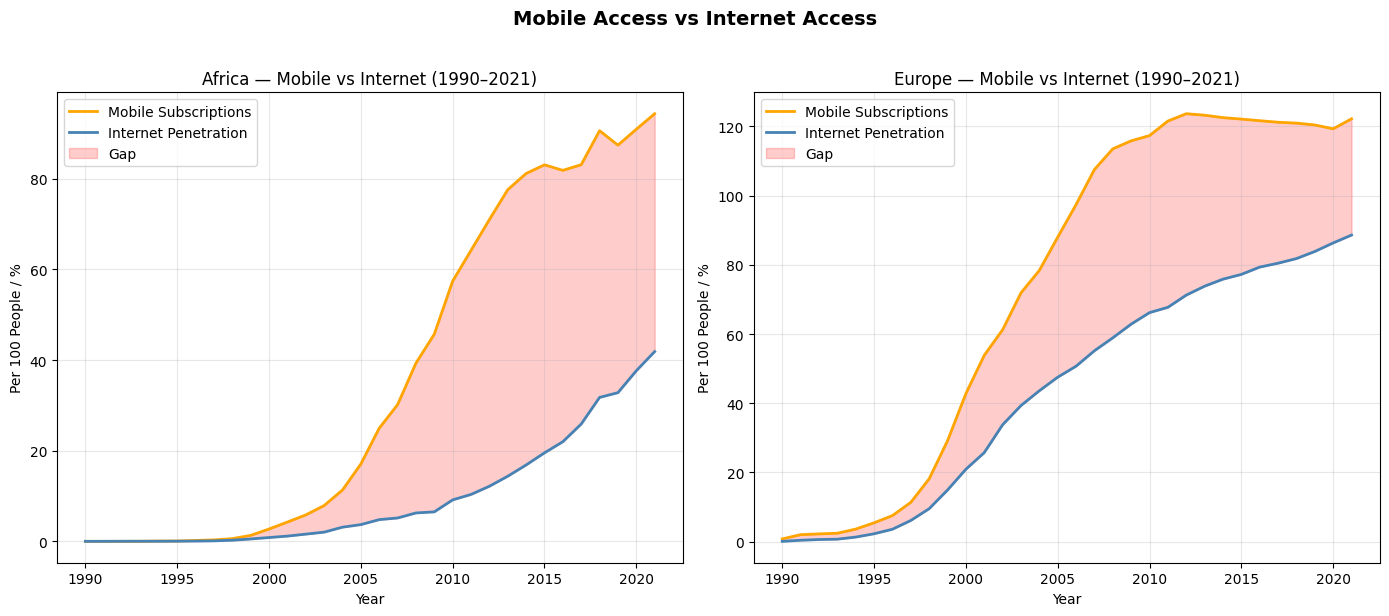

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, region in zip(axes, ['Africa', 'Europe']):
    data = regional_mobile[regional_mobile['Region'] == region]
    
    ax.plot(data['Year'], data['Avg_Mobile'],
            linewidth=2, color='orange', label='Mobile Subscriptions')
    ax.plot(data['Year'], data['Avg_Internet'],
            linewidth=2, color='steelblue', label='Internet Penetration')
    
    ax.fill_between(data['Year'], data['Avg_Mobile'], data['Avg_Internet'],
                    alpha=0.2, color='red', label='Gap')
    
    ax.set_title(f'{region} — Mobile vs Internet (1990–2021)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Per 100 People / %')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Mobile Access vs Internet Access', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

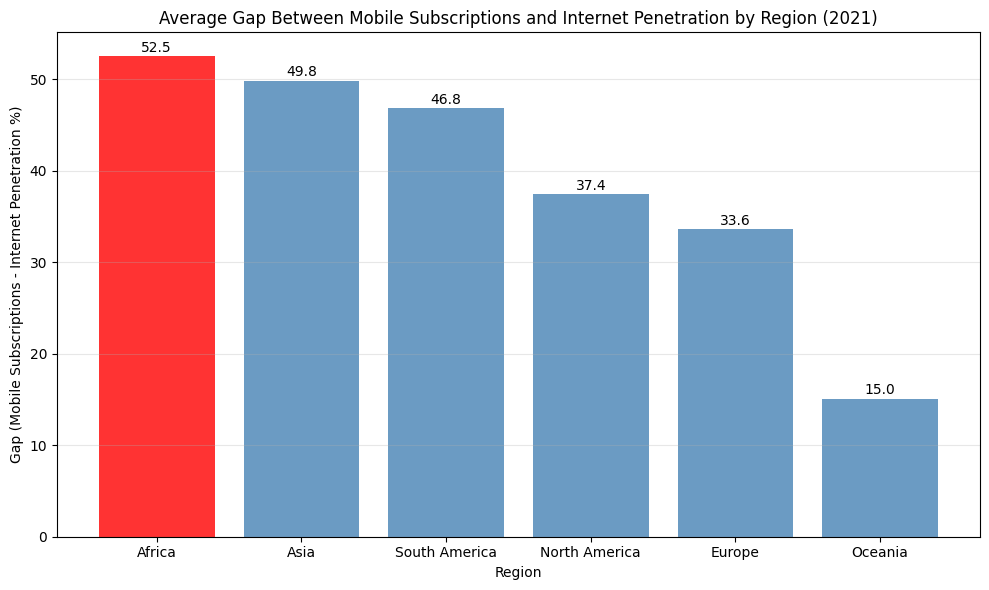

In [ ]:
gap_2021 = df[df['Year'] == 2021].groupby('Region')['Mobile_Internet_Gap'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['red' if r == 'Africa' else 'steelblue' for r in gap_2021.index]

bars = ax.bar(gap_2021.index, gap_2021.values, color=colors, alpha=0.8)

for bar, val in zip(bars, gap_2021.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=10)

ax.set_title('Average Gap Between Mobile Subscriptions and Internet Penetration by Region (2021)')
ax.set_xlabel('Region')
ax.set_ylabel('Gap (Mobile Subscriptions - Internet Penetration %)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
df_2000 = df[df['Year'] == 2000][['Country', 'Internet_Penetration(%)', 'Region']].rename(
    columns={'Internet_Penetration(%)': 'Penetration_2000'})

df_2021 = df[df['Year'] == 2021][['Country', 'Internet_Penetration(%)', 'Region']].rename(
    columns={'Internet_Penetration(%)': 'Penetration_2021'})

growth = df_2000.merge(df_2021, on=['Country', 'Region'], how='inner')
growth['Total_Growth'] = growth['Penetration_2021'] - growth['Penetration_2000']

top15 = growth.nlargest(15, 'Total_Growth')

print(top15[['Country', 'Region', 'Penetration_2000', 'Penetration_2021', 'Total_Growth']])

NameError: name 'df' is not defined

In [1]:
# Bar chart - Top 15 fastest growing countries
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['red' if r == 'Africa' else 'steelblue' for r in top15['Region']]

bars = ax.barh(top15['Country'], top15['Total_Growth'], color=colors, alpha=0.8)

for bar, val in zip(bars, top15['Total_Growth']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_title('Top 15 Countries by Internet Penetration Growth (2000–2021)')
ax.set_xlabel('Percentage Point Increase')
ax.set_ylabel('Country')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

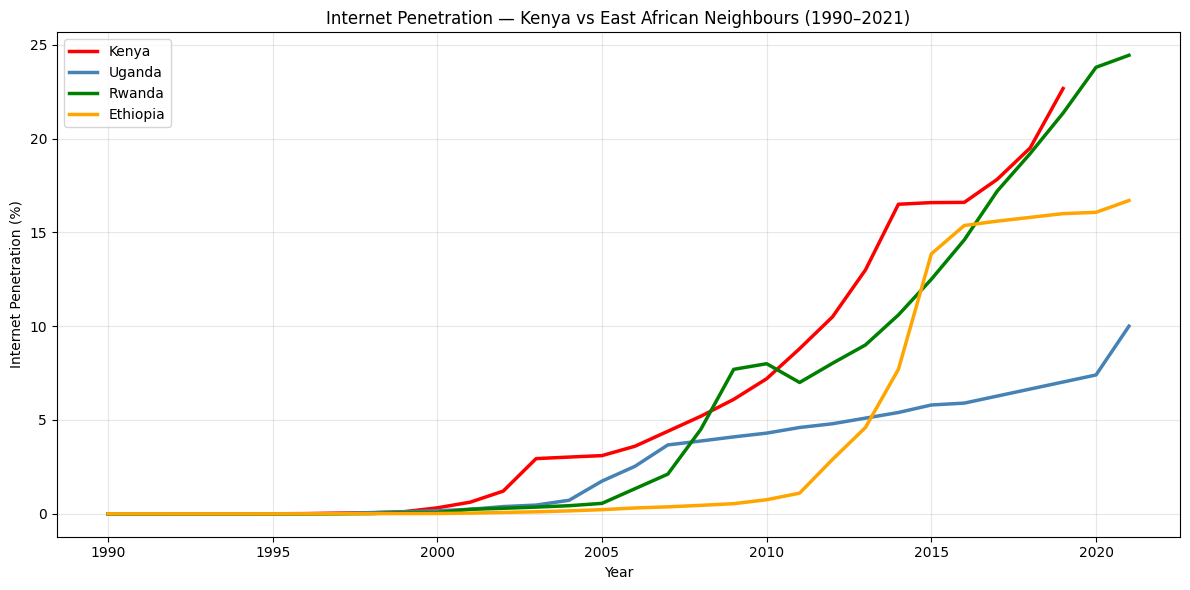

In [ ]:
ea_countries = ['Kenya', 'Uganda', 'Rwanda', 'Ethiopia']

ea_data = df[df['Country'].isin(ea_countries)]

fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'Kenya': 'red',
    'Uganda': 'steelblue',
    'Rwanda': 'green',
    'Ethiopia': 'orange'
}

for country in ea_countries:
    data = ea_data[ea_data['Country'] == country]
    ax.plot(data['Year'], data['Internet_Penetration(%)'],
            linewidth=2.5, label=country,
            color=colors[country])

ax.set_title('Internet Penetration — Kenya vs East African Neighbours (1990–2021)')
ax.set_xlabel('Year')
ax.set_ylabel('Internet Penetration (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [156]:
world = gpd.read_file("ne_110m_admin_0_countries.shp")
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


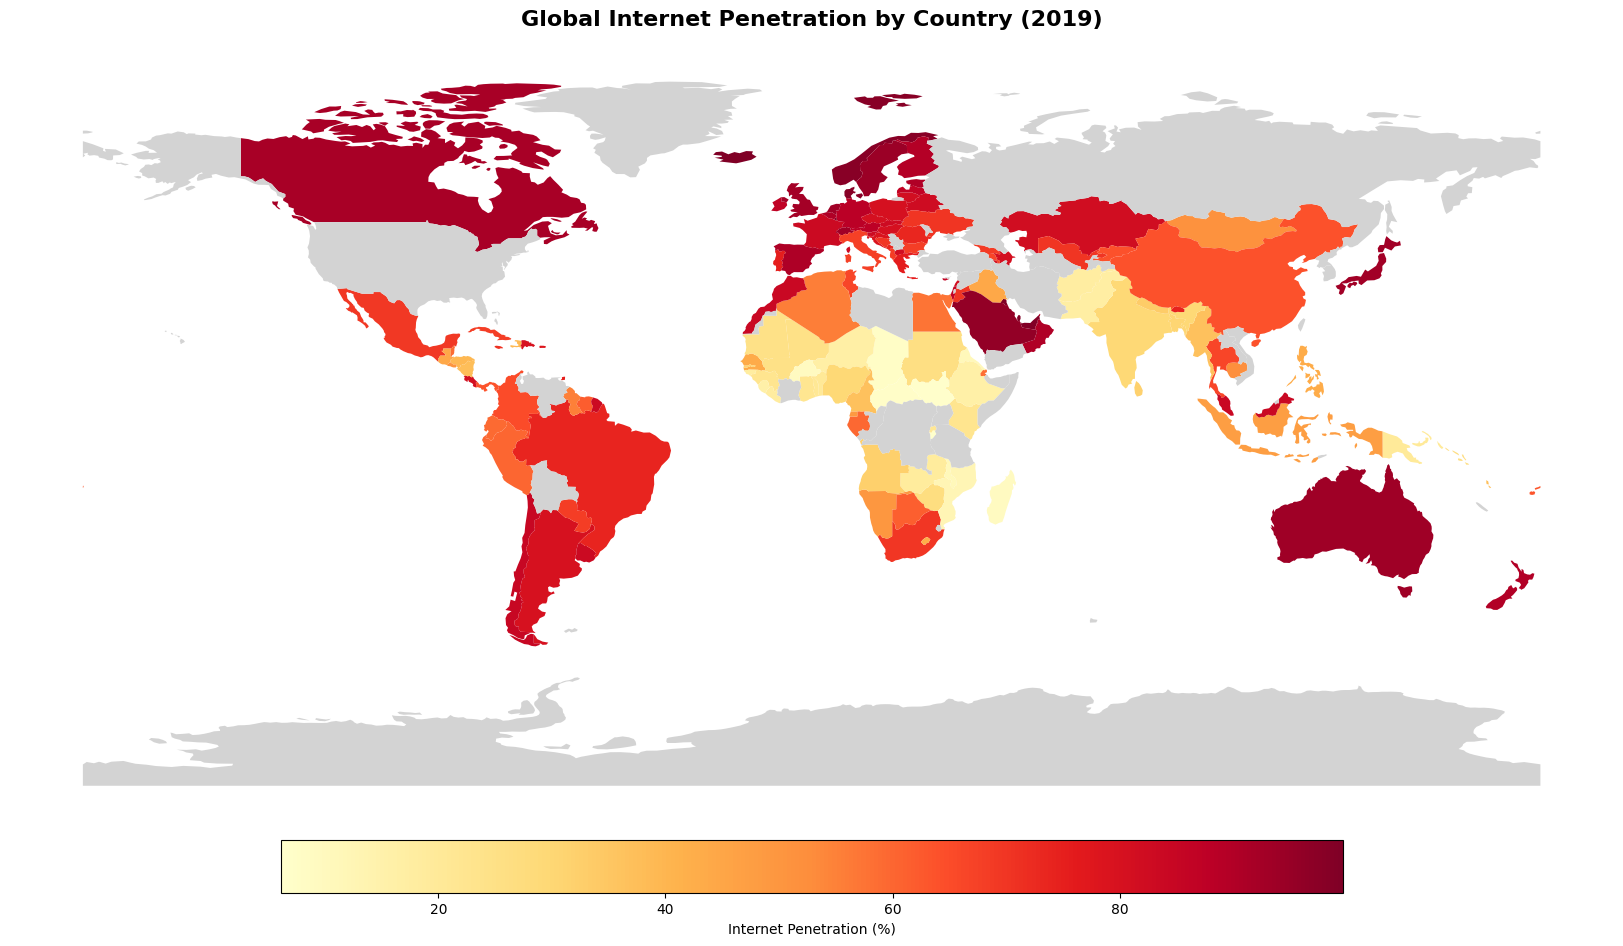

In [ ]:
df_2019_map = df[df['Year'] == 2019][['Country', 'Internet_Penetration(%)']].copy()

world_map = world.merge(df_2019_map,
                        left_on='ADMIN',
                        right_on='Country',
                        how='left')


fig, ax = plt.subplots(figsize=(18, 10))

world_map.plot(
    column='Internet_Penetration(%)',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    missing_kwds={
        'color': 'lightgrey',
        'label': 'No data'
    },
    legend_kwds={
        'label': 'Internet Penetration (%)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    }
)

ax.set_title('Global Internet Penetration by Country (2019)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_39704\3038853420.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


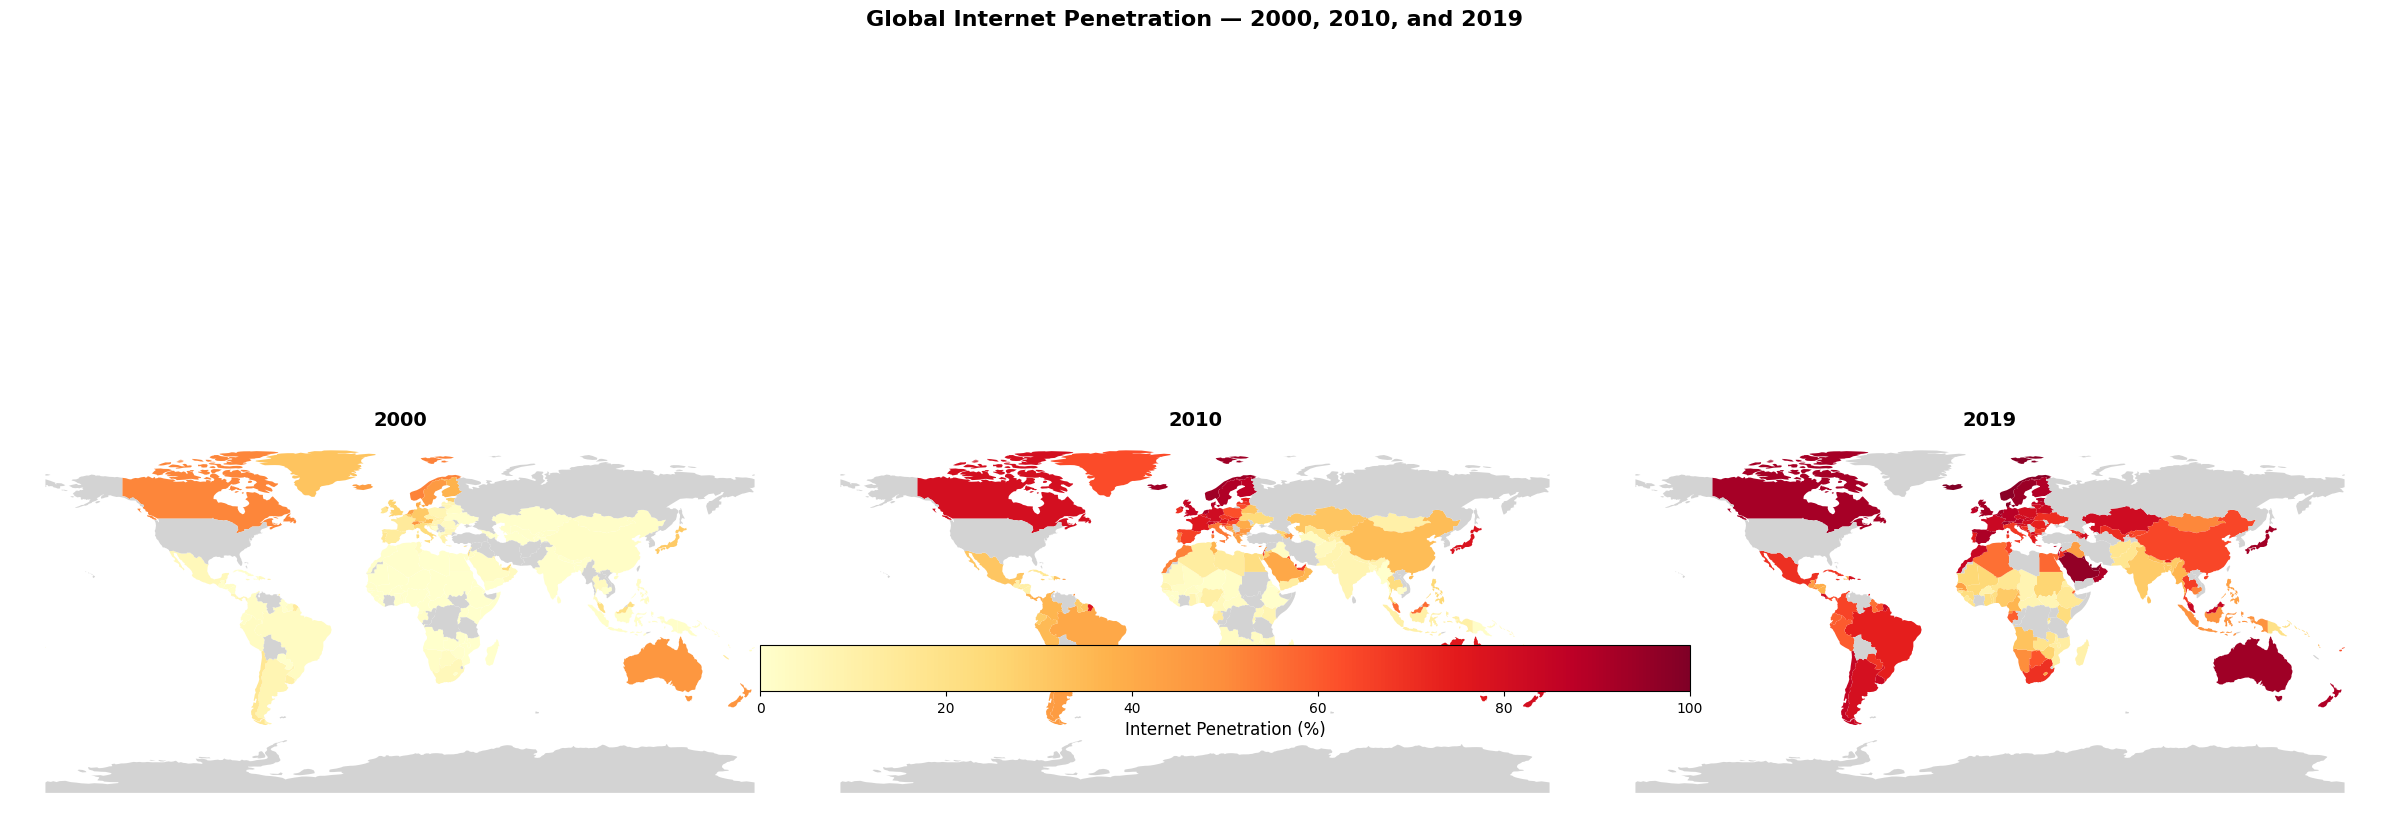

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

years = [2000, 2010, 2019]

for ax, year in zip(axes, years):
  
    df_year = df[df['Year'] == year][['Country', 'Internet_Penetration(%)']].copy()
    
   
    world_map = world.merge(df_year,
                            left_on='ADMIN',
                            right_on='Country',
                            how='left')
    

    world_map.plot(
        column='Internet_Penetration(%)',
        ax=ax,
        legend=False,
        cmap='YlOrRd',
        vmin=0,
        vmax=100,
        missing_kwds={
            'color': 'lightgrey',
            'label': 'No data'
        }
    )
    
    ax.set_title(f'{year}', fontsize=14, fontweight='bold')
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=0, vmax=100))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', 
                    shrink=0.5, pad=0.02)
cbar.set_label('Internet Penetration (%)', fontsize=12)

fig.suptitle('Global Internet Penetration — 2000, 2010, and 2019', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show();